,count,mean,std,min,25%,50%,75%,max
RMSE,10.0,54.921546,4.694823,48.039528,51.627448,56.231184,58.110907,61.274966


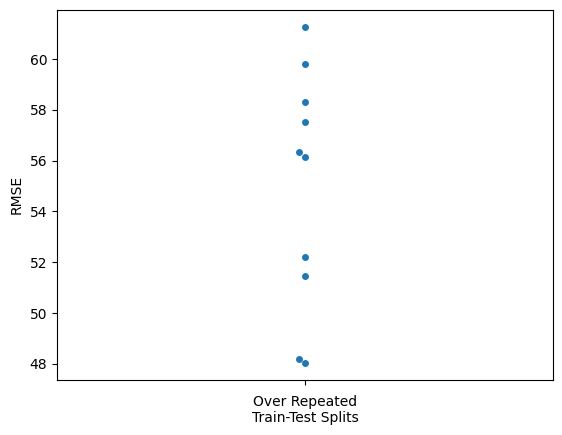

In [2]:
from sklearn import linear_model, datasets, model_selection as skms
import pandas as pd
import numpy as np
import seaborn as sns


linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
# nije zadano cv= argument
ss = skms.ShuffleSplit(test_size=.25) # default, 10 skupova
scores = skms.cross_val_score(linreg,
  diabetes.data, diabetes.target,
  cv=ss,
  scoring='neg_mean_squared_error')
scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.describe().T)
ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('Over Repeated\nTrain-Test Splits');